## Import Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Define Image Processing Function

In [ ]:
import cv2import numpy as npimport matplotlib.pyplot as pltfrom PIL import Imageimport io# Embedded production constants and helpers (copied verbatim from production core)ROI_SHRINK_RATIO = 0.12def _load_and_validate_image(file_bytes):    """Validate TIFF grayscale input and normalize any 16-bit NumPy dtype to uint16."""    try:        pil_img = Image.open(io.BytesIO(file_bytes))    except Exception as exc:        raise ValueError(f"Image format validation failed: unable to read image bytes ({exc}).") from exc    img_format = (pil_img.format or "unknown").upper()    if img_format != "TIFF":        raise ValueError(            f"Image format validation failed: expected 16-bit grayscale TIFF, got format '{img_format}'."        )    img = np.array(pil_img)    if img.ndim != 2:        raise ValueError(            f"Image format validation failed: expected grayscale TIFF (single channel), got shape {img.shape}."        )    if img.dtype.kind != "u" or img.dtype.itemsize != 2:        raise ValueError(            f"Image format validation failed: expected 16-bit grayscale TIFF, got dtype '{img.dtype}'."        )    return img.astype(np.uint16, copy=False)def _shrink_box(box, ratio=ROI_SHRINK_RATIO):    box_arr = np.array(box, dtype=np.float32)    center = np.mean(box_arr, axis=0, keepdims=True)    shrunk = center + (box_arr - center) * (1.0 - float(ratio))    return shrunk.astype(np.int32)def _mean_intensity_in_box(img_16bit, box, shrink_ratio=ROI_SHRINK_RATIO):    mask = np.zeros_like(img_16bit, dtype=np.uint8)    shrunk_box = _shrink_box(box, shrink_ratio)    cv2.drawContours(mask, [np.array(shrunk_box, dtype=np.int32)], 0, 255, -1)    pixel_values = img_16bit[mask == 255]    if len(pixel_values) == 0:        raise ValueError("ROI validation failed: no pixels inside shrunken ROI.")    return float(np.mean(pixel_values)), pixel_valuesdef process_image(    image_path,    threshold_value=55000,    min_length_rectangular=1400,    max_length_rectangular=1600,    min_rectangularity=0.9,    min_solidity=0.9,    return_data=False,):    """    Deteksi blok rectangular dalam gambar 16-bit dengan validasi bentuk.    """    # 1. Load Gambar 16-bit (validated via embedded production loader)    try:        with open(image_path, "rb") as _f:            _bytes = _f.read()        img_16bit = _load_and_validate_image(_bytes)    except Exception as exc:        print(f"Error: Gambar tidak ditemukan atau tidak valid TIFF (\n{exc}).")        return None if return_data else None    print(f"Dimensi Gambar: {img_16bit.shape}")    # 2. Thresholding    binary_mask = np.zeros_like(img_16bit, dtype=np.uint8)    binary_mask[img_16bit < threshold_value] = 255    # Bersihkan noise kecil menggunakan morfologi    kernel = np.ones((5, 5), np.uint8)    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=2)    # 3. Cari Kontur    contours, _ = cv2.findContours(        binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE    )    valid_blocks = []    print(f"Jumlah kontur awal ditemukan: {len(contours)}")    # 4. Filter kontur dengan validasi bentuk rectangular    for cnt in contours:        area = cv2.contourArea(cnt)        # Hitung properties dasar untuk rectangle        rect = cv2.minAreaRect(cnt)        box = cv2.boxPoints(rect)        box = box.astype(int)        center = (int(rect[0][0]), int(rect[0][1]))        rect_width, rect_height = rect[1]        # Normalize: width = pendek, height = panjang (untuk konsistensi)        width = min(rect_width, rect_height)        height = max(rect_width, rect_height)        longest_side = height        shortest_side = width        perimeter = cv2.arcLength(cnt, True)        if perimeter == 0:            continue        # Filter 1: Length constraints        if longest_side < min_length_rectangular or longest_side > max_length_rectangular:            continue        # Filter 2: Rectangularity (seberapa rectangular)        rect_area = width * height        if rect_area == 0:            continue        rectangularity = area / rect_area        if rectangularity < min_rectangularity:            continue        # Filter 3: Solidity (mengecek jika objek berlubang atau tidak solid)        hull = cv2.convexHull(cnt)        hull_area = cv2.contourArea(hull)        if hull_area == 0:            continue        solidity = area / hull_area        if solidity < min_solidity:            continue        # Semua filter passed - simpan block        valid_blocks.append(            {                "center": center,                "box": box,                "width": width,                "height": height,                "longest_side": longest_side,                "shortest_side": shortest_side,                "contour": cnt,                "area": area,                "rectangularity": rectangularity,                "solidity": solidity,            }        )    print(f"Setelah filtering bentuk: {len(valid_blocks)} objek valid")    # 5. Filter duplikat berdasarkan jarak    if len(valid_blocks) > 1:        # Hapus block yang terlalu dekat (duplikat)        filtered = []        for i, block in enumerate(valid_blocks):            is_duplicate = False            for j, other in enumerate(filtered):                # Hitung jarak antar center                dist = np.sqrt(                    (block["center"][0] - other["center"][0]) ** 2                    + (block["center"][1] - other["center"][1]) ** 2                )                # Jika jarak < rata-rata dimensi, anggap duplikat                avg_size = ((block["width"] + block["height"]) / 2 + (other["width"] + other["height"]) / 2) / 2                if dist < avg_size * 0.5:                    is_duplicate = True                    # Pilih yang rectangularity lebih tinggi                    if block["rectangularity"] > other["rectangularity"]:                        filtered[j] = block                    break            if not is_duplicate:                filtered.append(block)        valid_blocks = filtered        print(f"Setelah hapus duplikat: {len(valid_blocks)} objek")    # 6. Sorting berdasarkan posisi X (kiri ke kanan)    valid_blocks.sort(key=lambda c: c["center"][0])    # 7. Visualisasi & Klasifikasi    img_display = cv2.normalize(img_16bit, None, 0, 255, cv2.NORM_MINMAX).astype(        "uint8"    )    img_rgb = cv2.cvtColor(img_display, cv2.COLOR_GRAY2RGB)    debug_mask_rgb = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2RGB)    print("\n--- Data Deteksi Final ---")    print(        f"{'No':<4} | {'Posisi':<15} | {'W x H':<12} | {'Longest':<8} | {'Mean':<8} | {'Rect':<6} | {'Solid':<6} | {'Class'}"    )    print("-" * 100)    results = []    for i, item in enumerate(valid_blocks):        center = item["center"]        box = item["box"]        width = item["width"]        height = item["height"]        longest_side = item["longest_side"]        # Ambil mean menggunakan embedded shrunken ROI        try:            mean_val, _ = _mean_intensity_in_box(img_16bit, box, ROI_SHRINK_RATIO)        except Exception:            mean_val = float('nan')        # Klasifikasi Warna        if mean_val < 6000:            label = "Hitam"            color = (255, 0, 0)  # Merah        else:            label = "Abu-abu"            color = (0, 255, 0)  # Hijau        # Gambar di Output - draw rectangle        cv2.drawContours(img_rgb, [box], 0, color, 4)        cv2.putText(            img_rgb,            str(i + 1),            (center[0] - 20, center[1] + 10),            cv2.FONT_HERSHEY_SIMPLEX,            1.5,            (0, 100, 255),            4,        )        # Gambar di Mask Debug        cv2.drawContours(debug_mask_rgb, [box], 0, (0, 0, 255), 4)        cv2.putText(            debug_mask_rgb,            str(i + 1),            (center[0] - 20, center[1] + 10),            cv2.FONT_HERSHEY_SIMPLEX,            1.5,            (0, 100, 255),            4,        )        # Simpan hasil        result_item = {            "id": i + 1,            "center": center,            "box": box.tolist(),            "width": width,            "height": height,            "longest_side": longest_side,            "shortest_side": item["shortest_side"],            "mean_value": mean_val,            "classification": label,            "rectangularity": item["rectangularity"],            "solidity": item["solidity"],        }        results.append(result_item)        print(            f"{i+1:<4} | {str(center):<15} | {int(width)}x{int(height):<9} | {longest_side:<8.1f} | {mean_val:<8.1f} | "            f"{item['rectangularity']:<6.3f} | {item['solidity']:<6.3f} | {label}"        )    # Tampilkan visualisasi    fig, ax = plt.subplots(1, 2, figsize=(20, 10))    ax[0].imshow(img_rgb)    ax[0].set_title(f"Hasil Deteksi Blok ({len(valid_blocks)} Objek)")    ax[0].axis("off")    ax[1].imshow(debug_mask_rgb)    ax[1].set_title(        f"Masking Threshold < {threshold_value} (Cek kebersihan mask ini)"    )    ax[1].axis("off")    plt.tight_layout()    plt.show()    # Return data jika diminta    if return_data:        return {            "blocks": results,            "image_rgb": img_rgb,            "mask": binary_mask,            "count": len(results),        }

## Process Image

Specify the image file path and run the processing function.

Dimensi Gambar: (2048, 2448)
Jumlah kontur awal ditemukan: 163
Setelah filtering bentuk: 2 objek valid
Setelah hapus duplikat: 2 objek

--- Data Deteksi Final ---
No   | Posisi          | W x H        | Longest  | Mean     | Rect   | Solid  | Class
----------------------------------------------------------------------------------------------------
1    | (979, 1080)     | 272x1577      | 1577.8   | 23206.1  | 0.954  | 0.978  | Abu-abu
2    | (1853, 1081)    | 267x1563      | 1564.0   | 23630.3  | 0.946  | 0.965  | Abu-abu


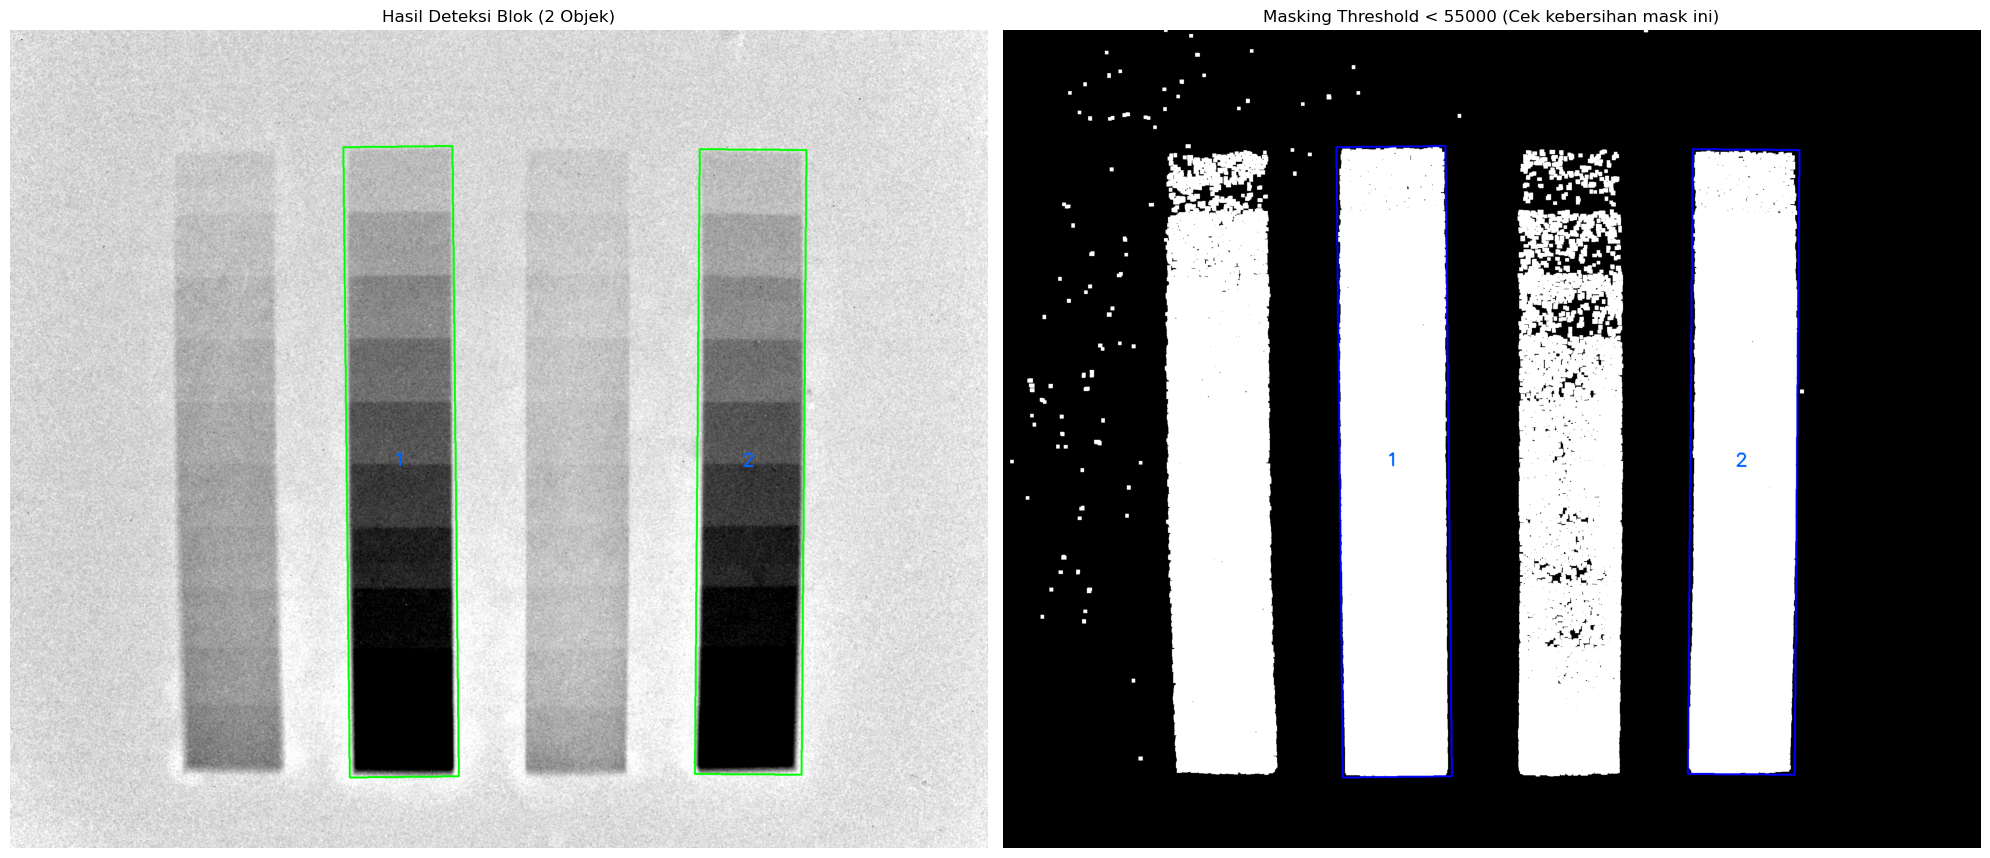

In [ ]:
image_file = r"H:\My Drive\Uji Sampel Batubara\5. 5 Desember 2025\1764905195920_processedimage.tiff"
process_image(image_file)

## Find Missing Blocks (1 and 3) Based on Detected Blocks (2 and 4)

Calculate positions of blocks 1 and 3 using the spacing (dx) between detected blocks 2 and 4.

Dimensi Gambar: (2048, 2448)
Jumlah kontur awal ditemukan: 163
Setelah filtering bentuk: 2 objek valid
Setelah hapus duplikat: 2 objek

--- Data Deteksi Final ---
No   | Posisi          | W x H        | Longest  | Mean     | Rect   | Solid  | Class
----------------------------------------------------------------------------------------------------
1    | (979, 1080)     | 272x1577      | 1577.8   | 23206.1  | 0.954  | 0.978  | Abu-abu
2    | (1853, 1081)    | 267x1563      | 1564.0   | 23630.3  | 0.946  | 0.965  | Abu-abu


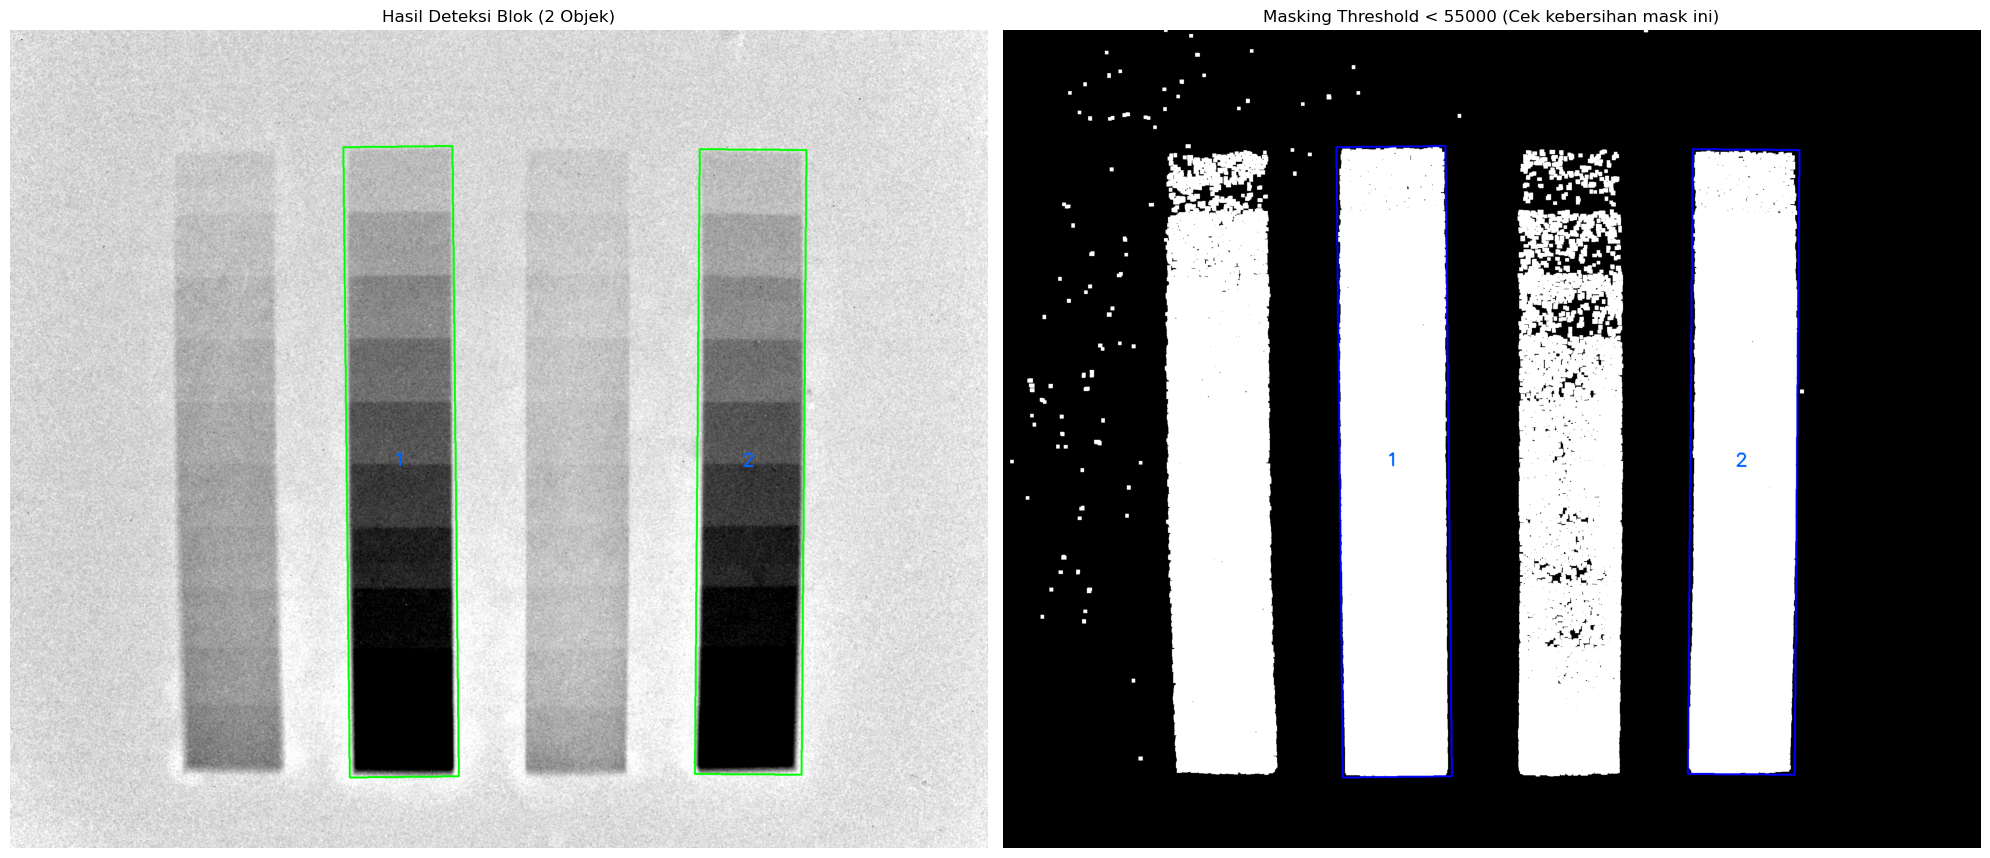

=== Kalkulasi Posisi Balok 1 dan 3 ===

Balok terdeteksi:
  Balok 2 (index 0): x = 979
  Balok 4 (index 1): x = 1853

Jarak antar balok (dx): 437.0

Posisi prediksi:
  Balok 1: x = 542.0
  Balok 3: x = 1416

Referensi dimensi dari balok 2:
  Width: 272.8
  Height: 1577.8
  Y position: 1080


In [ ]:
# Get hasil deteksi dari cell sebelumnya
image_file = r"H:\My Drive\Uji Sampel Batubara\5. 5 Desember 2025\1764905195920_processedimage.tiff"
initial_results = process_image(image_file, return_data=True)

if initial_results and initial_results['count'] >= 2:
    blocks = initial_results['blocks']
    
    # Balok yang terdeteksi: index 0 = balok 2, index 1 = balok 4
    block_2 = blocks[0]
    block_4 = blocks[1]
    
    x2 = block_2['center'][0]
    x4 = block_4['center'][0]
    
    # Hitung jarak antar balok (dx)
    # dx = rata-rata dari dua segmen: (x4-x3) dan (x3-x2)
    # Karena x3 belum diketahui, kita hitung x3 dulu sebagai titik tengah x2 dan x4
    x3_temp = (x2 + x4) // 2
    dx = abs(((x4 - x3_temp) + (x3_temp - x2)) / 2)
    
    # Hitung posisi center balok 3 (di tengah antara balok 2 dan 4)
    x3 = x3_temp
    
    # Hitung posisi center balok 1 (dx ke kiri dari balok 2)
    x1 = x2 - dx
    
    print("=== Kalkulasi Posisi Balok 1 dan 3 ===")
    print(f"\nBalok terdeteksi:")
    print(f"  Balok 2 (index 0): x = {x2}")
    print(f"  Balok 4 (index 1): x = {x4}")
    print(f"\nJarak antar balok (dx): {dx}")
    print(f"\nPosisi prediksi:")
    print(f"  Balok 1: x = {x1}")
    print(f"  Balok 3: x = {x3}")
    
    # Simpan untuk digunakan di cell berikutnya
    predicted_positions = {
        'x1': x1,
        'x3': x3,
        'dx': dx,
        'y_reference': block_2['center'][1],  # Gunakan y dari balok 2 sebagai referensi
        'width': block_2['width'],
        'height': block_2['height']
    }
    
    print(f"\nReferensi dimensi dari balok 2:")
    print(f"  Width: {block_2['width']:.1f}")
    print(f"  Height: {block_2['height']:.1f}")
    print(f"  Y position: {block_2['center'][1]}")
else:
    print("Error: Tidak cukup balok terdeteksi untuk kalkulasi.")


=== Menyusun 4 Balok dari Hasil Deteksi ===
Balok 2 dan 4 dari deteksi otomatis
Balok 1 dan 3 dari kalkulasi posisi

=== Total Balok Besar: 4 ===


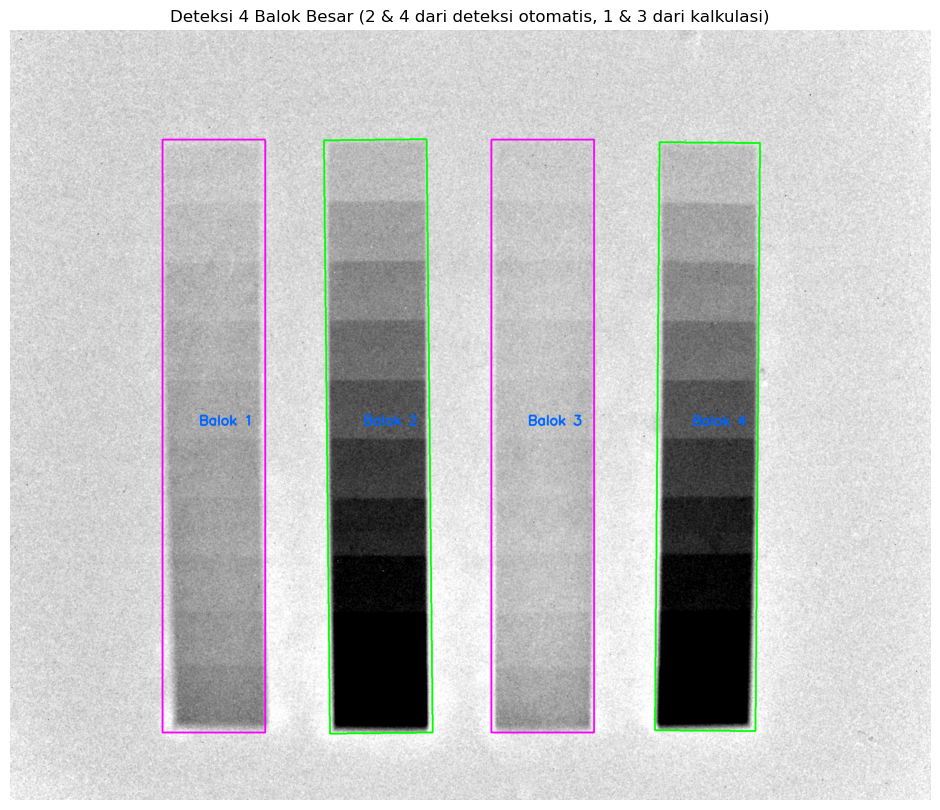


--- Detail Semua Balok ---
ID   | Posisi          | W x H        | Mean     | Class
----------------------------------------------------------------------
1    | (542, 1080)     | 272x1577      | 0.0      | Kalkulasi
2    | (979, 1080)     | 272x1577      | 23206.1  | Abu-abu
3    | (1416, 1080)    | 272x1577      | 0.0      | Kalkulasi
4    | (1853, 1081)    | 267x1563      | 23630.3  | Abu-abu


In [ ]:
# Gunakan hasil deteksi dari cell sebelumnya
# Langsung ambil blocks yang sudah terdeteksi (balok 2 dan 4)

# Load gambar hanya untuk visualisasi
img_16bit = cv2.imread(image_file, cv2.IMREAD_UNCHANGED)
img_display = cv2.normalize(img_16bit, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')
img_rgb = cv2.cvtColor(img_display, cv2.COLOR_GRAY2RGB)

print(f"\n=== Menyusun 4 Balok dari Hasil Deteksi ===")
print(f"Balok 2 dan 4 dari deteksi otomatis")
print(f"Balok 1 dan 3 dari kalkulasi posisi")

# Buat balok 1 dan 3 berdasarkan kalkulasi dari cell sebelumnya
# Balok 1: di posisi x1
# Balok 3: di posisi x3

# Gunakan dimensi dan properties dari balok 2 sebagai template
all_blocks = []

# Balok 1 (kalkulasi)
all_blocks.append({
    'id': 1,
    'center': (int(x1), predicted_positions['y_reference']),
    'box': np.array([
        [int(x1 - predicted_positions['width']/2), int(predicted_positions['y_reference'] - predicted_positions['height']/2)],
        [int(x1 + predicted_positions['width']/2), int(predicted_positions['y_reference'] - predicted_positions['height']/2)],
        [int(x1 + predicted_positions['width']/2), int(predicted_positions['y_reference'] + predicted_positions['height']/2)],
        [int(x1 - predicted_positions['width']/2), int(predicted_positions['y_reference'] + predicted_positions['height']/2)]
    ]),
    'width': predicted_positions['width'],
    'height': predicted_positions['height'],
    'mean_value': 0,  # Akan dihitung jika diperlukan
    'classification': 'Kalkulasi'
})

# Balok 2 (dari deteksi)
all_blocks.append({
    'id': 2,
    'center': block_2['center'],
    'box': np.array(block_2['box']),
    'width': block_2['width'],
    'height': block_2['height'],
    'mean_value': block_2['mean_value'],
    'classification': block_2['classification']
})

# Balok 3 (kalkulasi)
all_blocks.append({
    'id': 3,
    'center': (int(x3), predicted_positions['y_reference']),
    'box': np.array([
        [int(x3 - predicted_positions['width']/2), int(predicted_positions['y_reference'] - predicted_positions['height']/2)],
        [int(x3 + predicted_positions['width']/2), int(predicted_positions['y_reference'] - predicted_positions['height']/2)],
        [int(x3 + predicted_positions['width']/2), int(predicted_positions['y_reference'] + predicted_positions['height']/2)],
        [int(x3 - predicted_positions['width']/2), int(predicted_positions['y_reference'] + predicted_positions['height']/2)]
    ]),
    'width': predicted_positions['width'],
    'height': predicted_positions['height'],
    'mean_value': 0,  # Akan dihitung jika diperlukan
    'classification': 'Kalkulasi'
})

# Balok 4 (dari deteksi)
all_blocks.append({
    'id': 4,
    'center': block_4['center'],
    'box': np.array(block_4['box']),
    'width': block_4['width'],
    'height': block_4['height'],
    'mean_value': block_4['mean_value'],
    'classification': block_4['classification']
})

# Visualisasi
print(f"\n=== Total Balok Besar: {len(all_blocks)} ===")
for block in all_blocks:
    # Warna: biru untuk kalkulasi, hijau untuk abu-abu, merah untuk hitam
    if block['classification'] == 'Kalkulasi':
        color = (255, 0, 255)  # Magenta untuk kalkulasi
    elif block['classification'] == 'Abu-abu':
        color = (0, 255, 0)  # Hijau
    else:
        color = (255, 0, 0)  # Merah
    
    cv2.drawContours(img_rgb, [block['box']], 0, color, 4)
    cv2.putText(img_rgb, f"Balok {block['id']}", 
                (block['center'][0] - 40, block['center'][1] - 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 100, 255), 3)

plt.figure(figsize=(15, 10))
plt.imshow(img_rgb)
plt.title(f'Deteksi 4 Balok Besar (2 & 4 dari deteksi otomatis, 1 & 3 dari kalkulasi)')
plt.axis('off')
plt.show()

print("\n--- Detail Semua Balok ---")
print(f"{'ID':<4} | {'Posisi':<15} | {'W x H':<12} | {'Mean':<8} | {'Class'}")
print("-" * 70)
for block in all_blocks:
    print(f"{block['id']:<4} | {str(block['center']):<15} | "
          f"{int(block['width'])}x{int(block['height']):<9} | "
          f"{block['mean_value']:<8.1f} | {block['classification']}")

## Subdivide Large Blocks into 10 Smaller Grids

Divide each detected large block into 10 equal subdivisions along its longest side, creating smaller blocks with 2/3 area of each subdivision.

=== SUBDIVISI SEMUA BALOK MENJADI 10 GRID (Scale: 0.6666666666666666) ===
Balok 1 & 3: dari all_blocks (kalkulasi)
Balok 2 & 4: dari deteksi otomatis

--- BALOK 1 ---
Center: (542, 1080)
Dimensi: 272.8 x 1577.8
Orientasi: Vertical
Ukuran subdivisi penuh: 157.8 x 272.8
Ukuran balok kecil (2/3): 105.2 x 181.8

Sub  | Center               | Box Corners
----------------------------------------------------------------------------------------------------
1    | (541, 369)           | [450 421] ...
2    | (541, 527)           | [450 579] ...
3    | (541, 685)           | [450 737] ...
4    | (541, 843)           | [450 895] ...
5    | (541, 1001)          | [ 450 1053] ...
6    | (541, 1158)          | [ 450 1210] ...
7    | (541, 1316)          | [ 450 1368] ...
8    | (541, 1474)          | [ 450 1526] ...
9    | (541, 1632)          | [ 450 1684] ...
10   | (541, 1789)          | [ 450 1841] ...

--- BALOK 2 ---
Center: (979, 1080)
Dimensi: 272.8 x 1577.8
Orientasi: Vertical
Ukuran subdivi

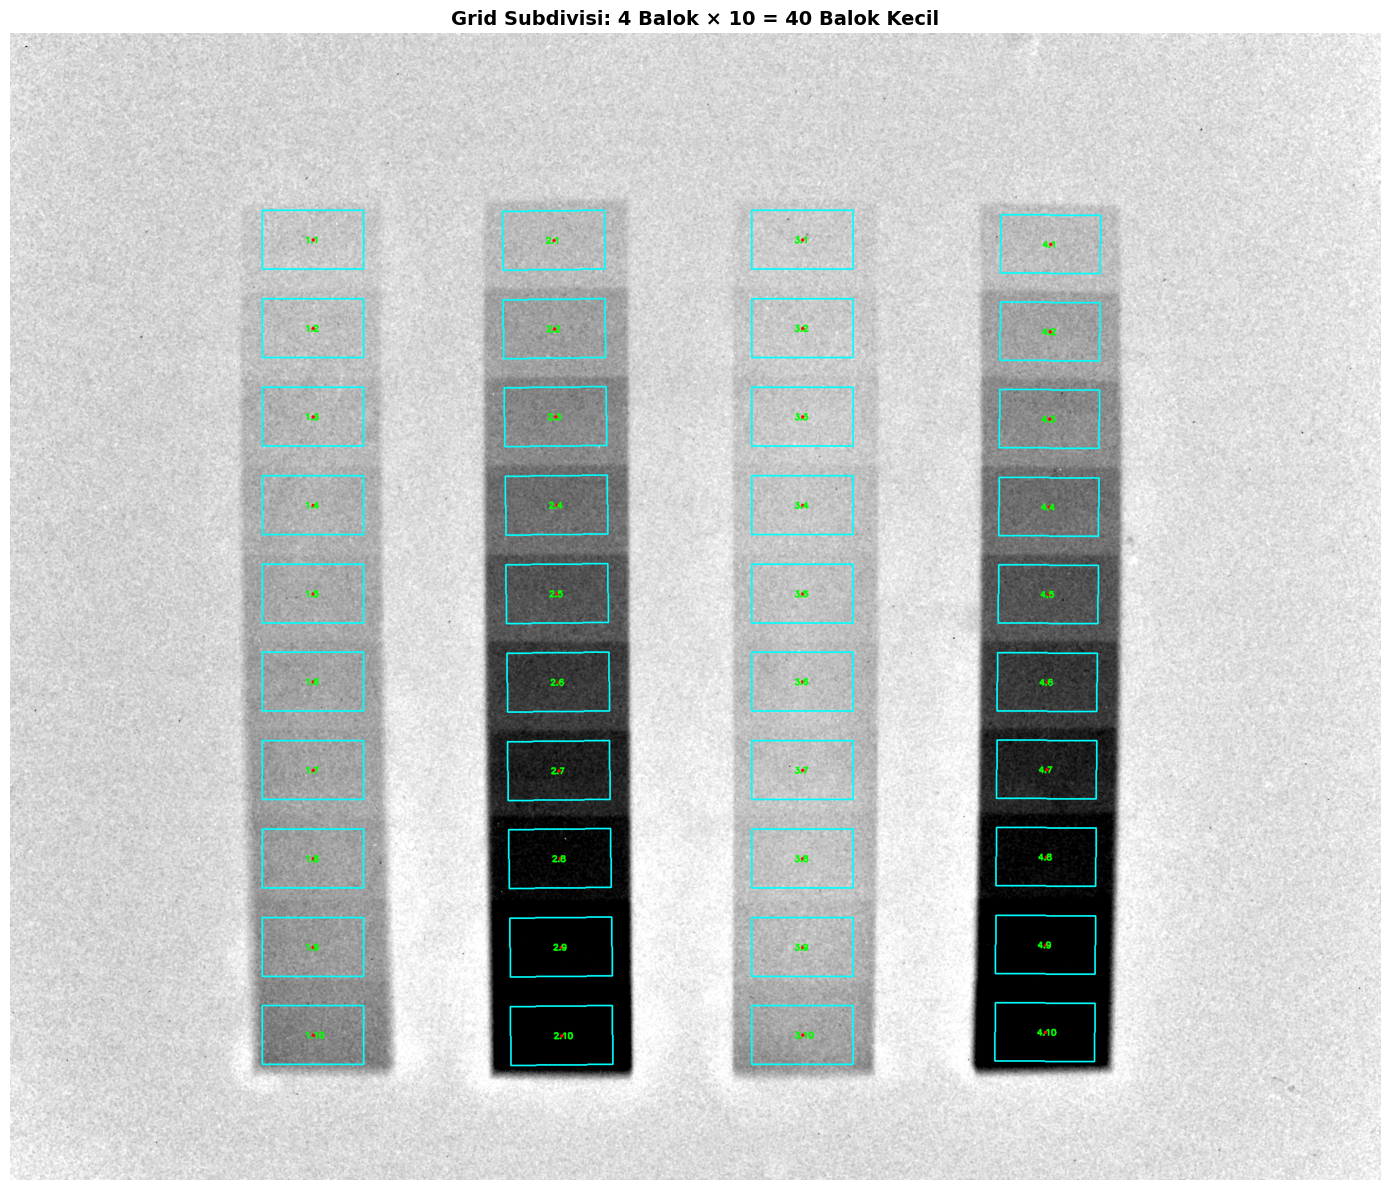


Total subdivisi: 40 balok kecil (dari 4 balok besar)


In [ ]:
def subdivide_blocks_into_grid(image_path, all_blocks_data, initial_results, num_subdivisions=10, scale_factor=2/3):
    """
    Bagi semua balok menjadi subdivisi kecil sepanjang sisi terpanjangnya.
    Balok 1 & 3 dari all_blocks_data, balok 2 & 4 dari initial_results.
    
    Parameters:
    -----------
    image_path : str
        Path ke file gambar
    all_blocks_data : list
        List dari all_blocks (balok 1, 2, 3, 4) - ambil balok 1 & 3
    initial_results : dict
        Hasil dari process_image - ambil balok 2 & 4
    num_subdivisions : int
        Jumlah subdivisi (default: 10)
    scale_factor : float
        Faktor skala untuk ukuran balok kecil dari hasil pembagian (default: 2/3)
    
    Returns:
    --------
    dict
        Dictionary berisi informasi grid subdivisi untuk semua balok
    """
    # Load gambar
    img_16bit = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img_16bit is None:
        print("Error: Gambar tidak ditemukan.")
        return None
    
    # Gabungkan balok 1 & 3 dari all_blocks dengan balok 2 & 4 dari initial_results
    blocks = []
    
    # Balok 1 dari all_blocks
    block_1 = next((b for b in all_blocks_data if b['id'] == 1), None)
    if block_1:
        blocks.append(block_1)
    
    # Balok 2 dari initial_results
    if initial_results and len(initial_results['blocks']) >= 1:
        block_2 = initial_results['blocks'][0]
        blocks.append({
            'id': 2,
            'center': block_2['center'],
            'box': np.array(block_2['box']),
            'width': block_2['width'],
            'height': block_2['height']
        })
    
    # Balok 3 dari all_blocks
    block_3 = next((b for b in all_blocks_data if b['id'] == 3), None)
    if block_3:
        blocks.append(block_3)
    
    # Balok 4 dari initial_results
    if initial_results and len(initial_results['blocks']) >= 2:
        block_4 = initial_results['blocks'][1]
        blocks.append({
            'id': 4,
            'center': block_4['center'],
            'box': np.array(block_4['box']),
            'width': block_4['width'],
            'height': block_4['height']
        })
    
    # Visualisasi
    img_display = cv2.normalize(img_16bit, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')
    img_rgb = cv2.cvtColor(img_display, cv2.COLOR_GRAY2RGB)
    
    all_subdivisions = []
    
    print("=" * 100)
    print(f"=== SUBDIVISI SEMUA BALOK MENJADI {num_subdivisions} GRID (Scale: {scale_factor}) ===")
    print(f"Balok 1 & 3: dari all_blocks (kalkulasi)")
    print(f"Balok 2 & 4: dari deteksi otomatis")
    print("=" * 100)
    
    for block in blocks:
        block_id = block['id']
        print(f"\n--- BALOK {block_id} ---")
        print(f"Center: {block['center']}")
        print(f"Dimensi: {block['width']:.1f} x {block['height']:.1f}")
        
        # Balok 1 dan 3 adalah vertikal - subdivisi sepanjang HEIGHT
        is_horizontal = False
        actual_length = block['height']  # Panjang = height
        actual_width = block['width']    # Lebar = width
        
        # Ukuran subdivisi sebelum scaling
        subdivision_length = actual_length / num_subdivisions
        subdivision_width = actual_width
        
        # Ukuran balok kecil setelah scaling (2/3)
        small_length = subdivision_length * scale_factor
        small_width = subdivision_width * scale_factor
        
        print(f"Orientasi: {'Horizontal' if is_horizontal else 'Vertical'}")
        print(f"Ukuran subdivisi penuh: {subdivision_length:.1f} x {subdivision_width:.1f}")
        print(f"Ukuran balok kecil (2/3): {small_length:.1f} x {small_width:.1f}")
        
        # Generate center positions untuk setiap subdivisi
        subdivisions = []
        
        # Dapatkan info dari box (rotated rectangle)
        box = np.array(block['box'])
        center = block['center']
        
        # Hitung vektor arah sepanjang sisi terpanjang
        if is_horizontal:
            # Untuk horizontal: iterasi sepanjang X
            # Estimasi titik awal dan akhir dari longest side
            # Ambil 2 titik box yang membentuk sisi panjang
            box_sorted_x = sorted(box, key=lambda p: p[0])
            left_point = np.mean([box_sorted_x[0], box_sorted_x[1]], axis=0)
            right_point = np.mean([box_sorted_x[2], box_sorted_x[3]], axis=0)
            
            direction_vector = right_point - left_point
            direction_unit = direction_vector / np.linalg.norm(direction_vector)
            
            # Perpendicular vector untuk lebar
            perp_vector = np.array([-direction_unit[1], direction_unit[0]])
            
        else:
            # Untuk vertical: iterasi sepanjang Y
            box_sorted_y = sorted(box, key=lambda p: p[1])
            top_point = np.mean([box_sorted_y[0], box_sorted_y[1]], axis=0)
            bottom_point = np.mean([box_sorted_y[2], box_sorted_y[3]], axis=0)
            
            direction_vector = bottom_point - top_point
            direction_unit = direction_vector / np.linalg.norm(direction_vector)
            
            # Perpendicular vector untuk lebar
            perp_vector = np.array([-direction_unit[1], direction_unit[0]])
        
        # Titik awal (ujung pertama balok besar)
        start_point = left_point if is_horizontal else top_point
        
        print(f"\n{'Sub':<4} | {'Center':<20} | {'Box Corners'}")
        print("-" * 100)
        
        for i in range(num_subdivisions):
            # Hitung center subdivisi ke-i
            # Center berada di tengah setiap subdivisi penuh (belum scaled)
            offset_along_length = (i + 0.5) * subdivision_length
            sub_center = start_point + direction_unit * offset_along_length
            sub_center = (int(sub_center[0]), int(sub_center[1]))
            
            # Hitung 4 corner points untuk balok kecil (dengan ukuran scaled)
            half_length = small_length / 2
            half_width = small_width / 2
            
            # 4 corners dari balok kecil
            corners = [
                sub_center + direction_unit * half_length + perp_vector * half_width,
                sub_center + direction_unit * half_length - perp_vector * half_width,
                sub_center - direction_unit * half_length - perp_vector * half_width,
                sub_center - direction_unit * half_length + perp_vector * half_width,
            ]
            
            small_box = np.array(corners, dtype=np.int32)
            
            subdivisions.append({
                'parent_block': block_id,
                'subdivision_id': i + 1,
                'center': sub_center,
                'box': small_box,
                'length': small_length,
                'width': small_width,
                'orientation': 'horizontal' if is_horizontal else 'vertical'
            })
            
            # Gambar balok kecil
            cv2.drawContours(img_rgb, [small_box], 0, (0, 255, 255), 2)
            cv2.circle(img_rgb, sub_center, 3, (255, 0, 0), -1)
            
            # Label
            label = f"{block_id}.{i + 1}"
            cv2.putText(img_rgb, label, (sub_center[0] - 15, sub_center[1] + 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            
            print(f"{i+1:<4} | {str(sub_center):<20} | {small_box[0]} ...")
        
        all_subdivisions.extend(subdivisions)
    
    # Tampilkan hasil
    plt.figure(figsize=(16, 12))
    plt.imshow(img_rgb)
    plt.title(f"Grid Subdivisi: 4 Balok × {num_subdivisions} = {len(all_subdivisions)} Balok Kecil", 
             fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 100)
    print(f"Total subdivisi: {len(all_subdivisions)} balok kecil (dari 4 balok besar)")
    print("=" * 100)
    
    return {
        'subdivisions': all_subdivisions,
        'image': img_rgb,
        'num_blocks': len(blocks),
        'num_subdivisions': num_subdivisions,
        'scale_factor': scale_factor
    }


# Run subdivisi untuk semua balok (1 & 3 dari all_blocks, 2 & 4 dari initial_results)
if 'all_blocks' in locals() and 'initial_results' in locals():
    grid_subdivisions = subdivide_blocks_into_grid(image_file, all_blocks, initial_results, num_subdivisions=10, scale_factor=2/3)
else:
    print("Run cell sebelumnya terlebih dahulu untuk mendapatkan all_blocks dan initial_results.")

## Analyze Histogram for Each Subdivision

Plot histogram untuk setiap balok kecil hasil subdivisi.

=== STATISTIK SUBDIVISI BALOK 1 ===
Sub  | Center               | Mean       | Median     | Std        | Range
----------------------------------------------------------------------------------------------------
1    | (541, 369)           | 51250.4    | 51162.0    | 2596.7     | [33003-65535]
2    | (541, 527)           | 49042.4    | 49101.0    | 2501.4     | [17099-58968]
3    | (541, 685)           | 46572.8    | 46566.0    | 2673.1     | [29662-57395]
4    | (541, 843)           | 45191.2    | 45185.0    | 2549.7     | [34990-56535]
5    | (541, 1001)          | 43336.2    | 43297.0    | 2429.8     | [20251-52346]
6    | (541, 1158)          | 41575.2    | 41604.0    | 2468.1     | [24429-52582]
7    | (541, 1316)          | 41518.2    | 41534.0    | 2652.8     | [31063-65535]
8    | (541, 1474)          | 40904.7    | 40933.0    | 2635.7     | [30407-51292]
9    | (541, 1632)          | 39032.6    | 39051.0    | 2681.9     | [733-57101]
10   | (541, 1789)          | 33568.6    | 

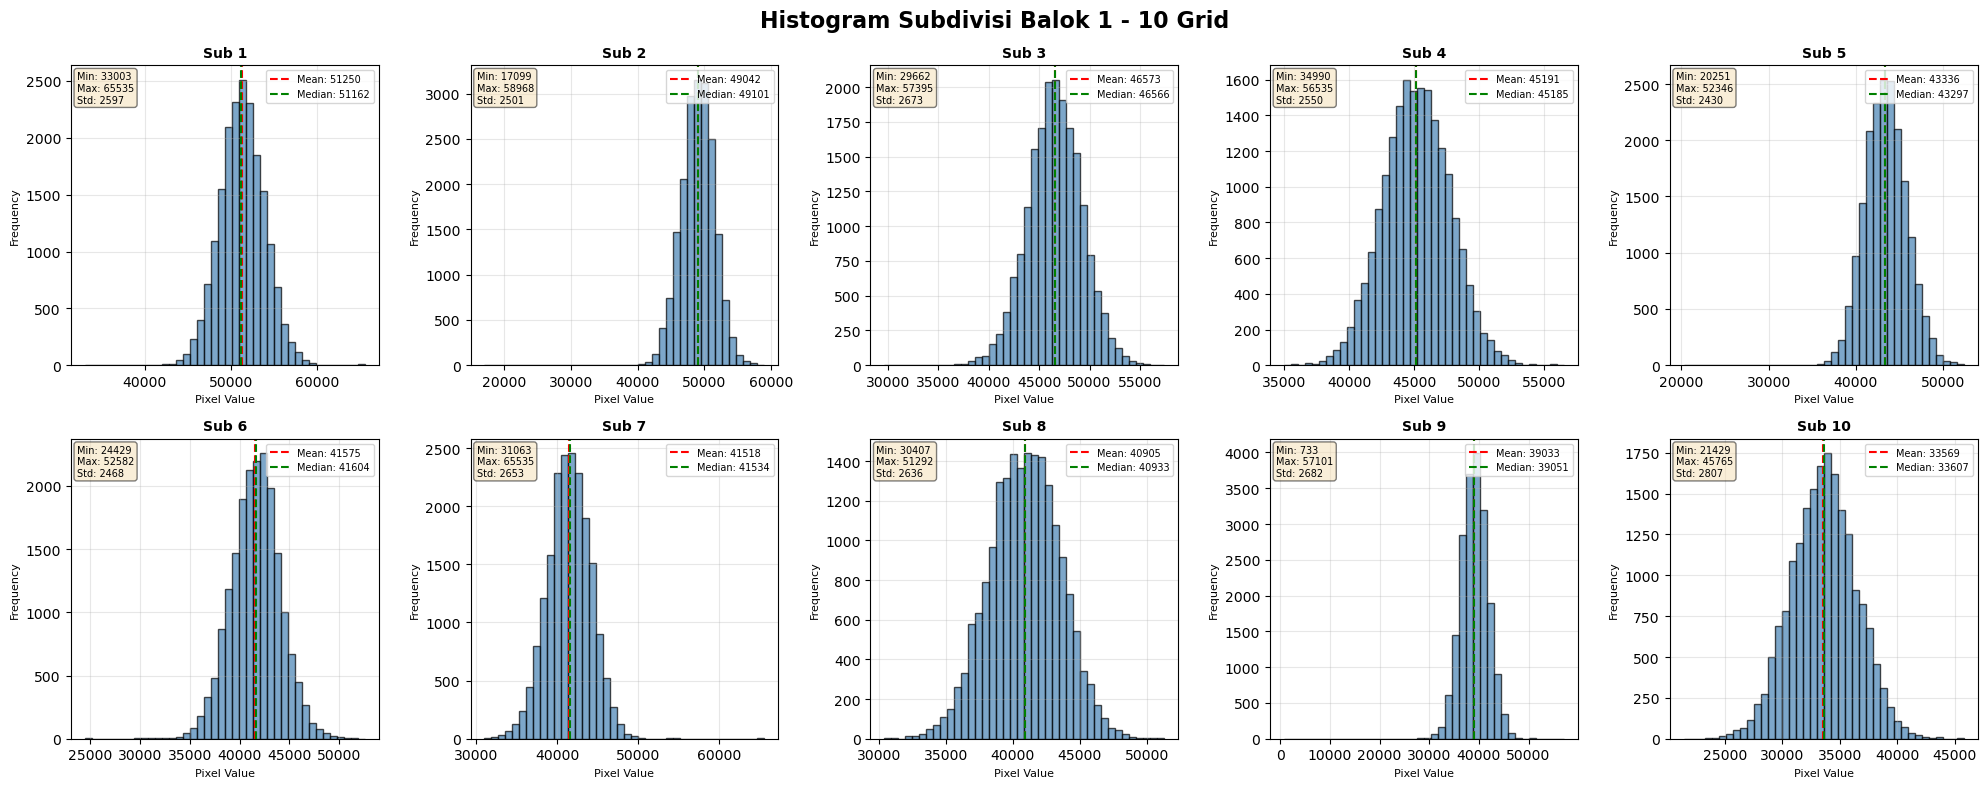

=== STATISTIK SUBDIVISI BALOK 2 ===
Sub  | Center               | Mean       | Median     | Std        | Range
----------------------------------------------------------------------------------------------------
1    | (971, 370)           | 47844.6    | 47831.0    | 2321.0     | [23722-61459]
2    | (972, 528)           | 40819.4    | 40836.0    | 2312.5     | [32451-53369]
3    | (974, 685)           | 34617.1    | 34652.0    | 2342.7     | [21321-49540]
4    | (976, 843)           | 28007.8    | 27956.0    | 2312.8     | [16629-37885]
5    | (977, 1001)          | 21437.1    | 21472.0    | 2248.1     | [13079-33942]
6    | (979, 1159)          | 14643.5    | 14656.0    | 2243.3     | [5326-29016]
=== STATISTIK SUBDIVISI BALOK 2 ===
Sub  | Center               | Mean       | Median     | Std        | Range
----------------------------------------------------------------------------------------------------
1    | (971, 370)           | 47844.6    | 47831.0    | 2321.0     | [23722-614

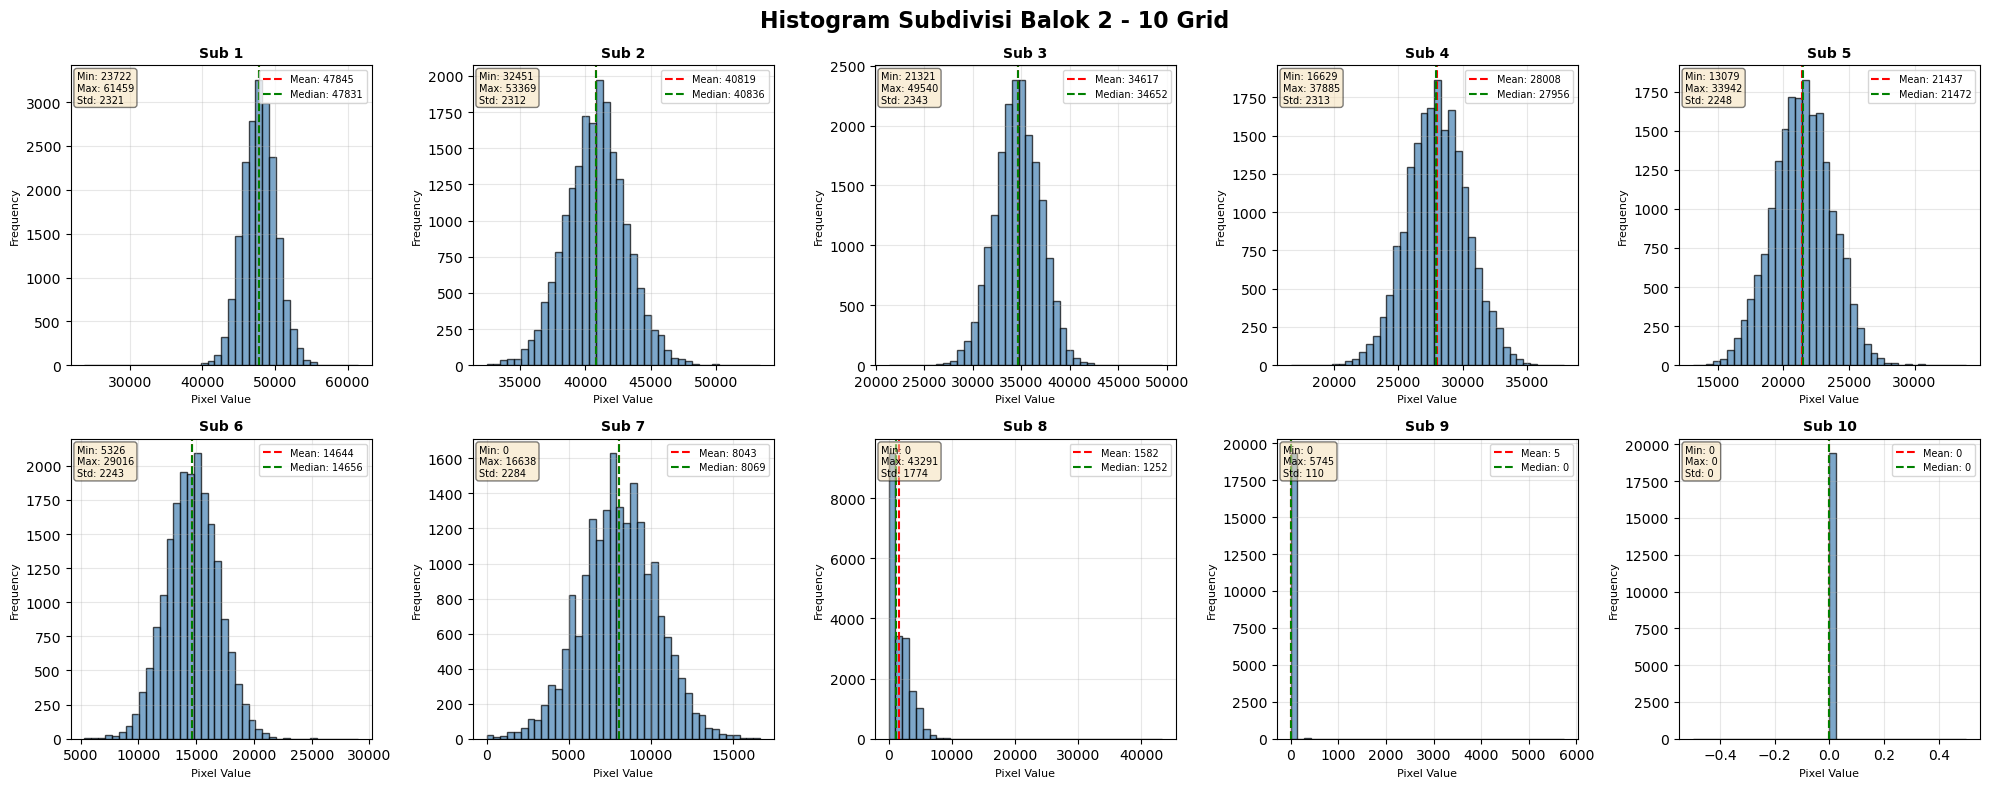

=== STATISTIK SUBDIVISI BALOK 3 ===
Sub  | Center               | Mean       | Median     | Std        | Range
----------------------------------------------------------------------------------------------------
1    | (1415, 369)          | 52387.1    | 52383.0    | 2450.7     | [22432-64296]
2    | (1415, 527)          | 51847.1    | 51822.0    | 2467.0     | [40276-65535]
3    | (1415, 685)          | 51529.6    | 51610.0    | 2443.1     | [37272-63444]
4    | (1415, 843)          | 50582.8    | 50612.0    | 2388.6     | [14130-62576]
5    | (1415, 1001)         | 49670.4    | 49722.0    | 2340.3     | [40336-59961]
6    | (1415, 1158)         | 48968.4    | 49027.0    | 2489.1     | [20939-65535]
=== STATISTIK SUBDIVISI BALOK 3 ===
Sub  | Center               | Mean       | Median     | Std        | Range
----------------------------------------------------------------------------------------------------
1    | (1415, 369)          | 52387.1    | 52383.0    | 2450.7     | [22432-64

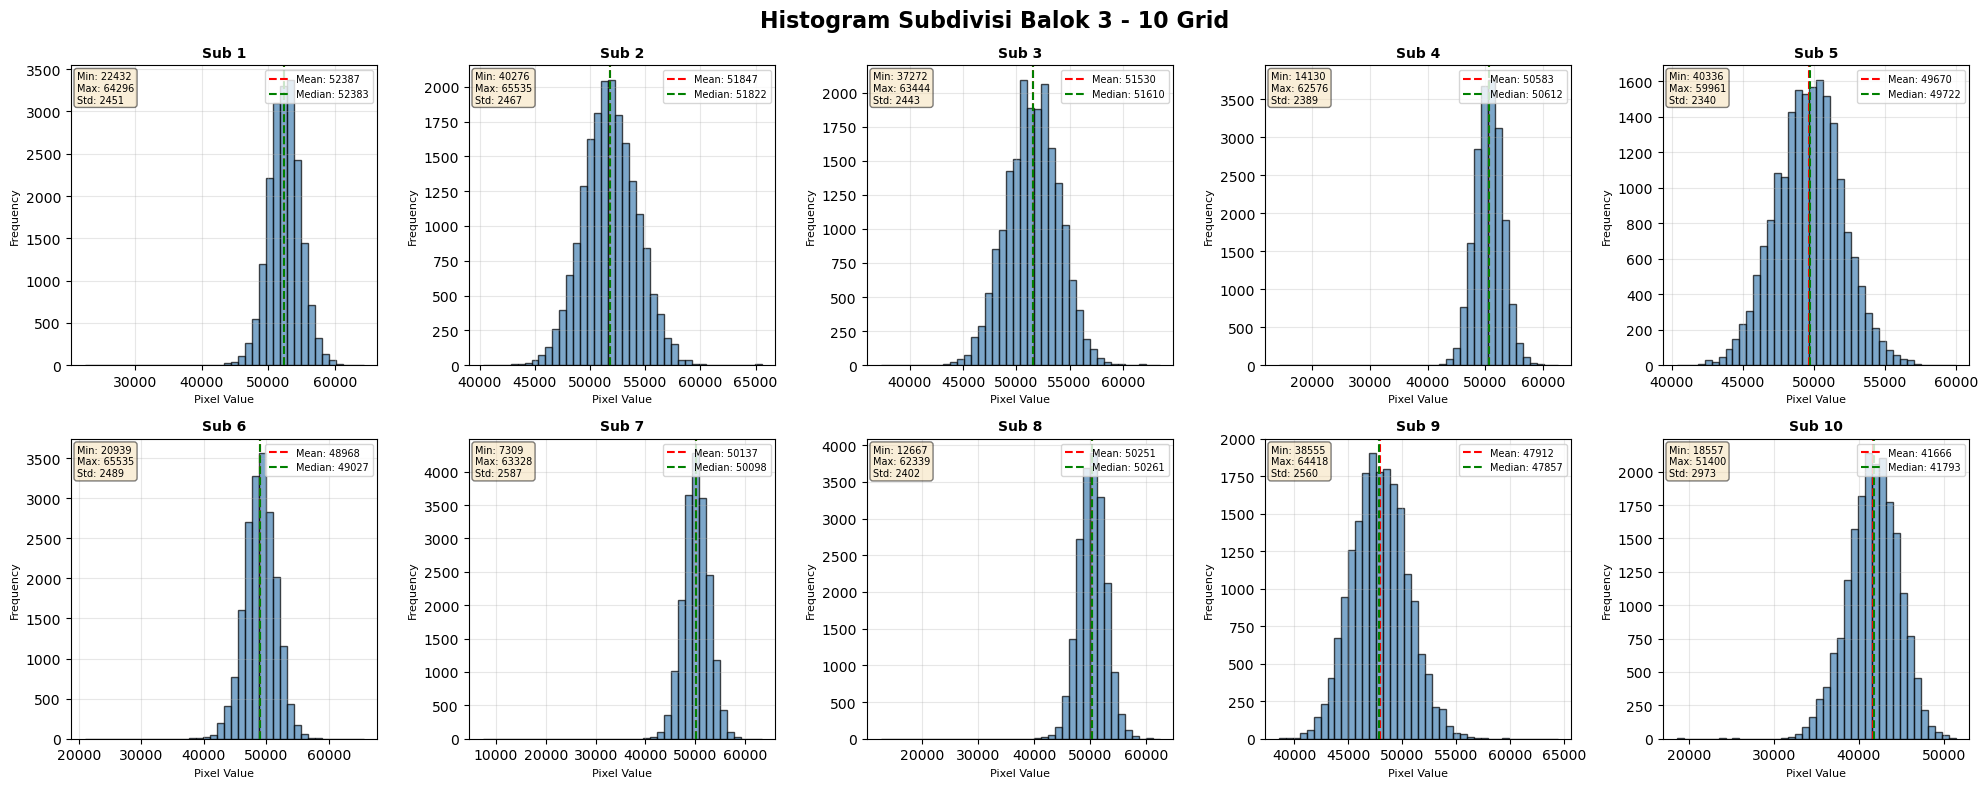

=== STATISTIK SUBDIVISI BALOK 4 ===
Sub  | Center               | Mean       | Median     | Std        | Range
----------------------------------------------------------------------------------------------------
1    | (1858, 377)          | 48525.3    | 48477.0    | 2439.2     | [38105-60509]
2    | (1857, 533)          | 41906.4    | 41863.0    | 2427.7     | [31234-51402]
3    | (1856, 689)          | 35524.4    | 35524.0    | 2493.6     | [3691-45089]
4    | (1855, 846)          | 28435.9    | 28403.0    | 2316.2     | [17648-37053]
5    | (1854, 1002)         | 21310.1    | 21253.0    | 2323.2     | [0-43600]
6    | (1852, 1159)         | 14512.3    | 14548.0    | 2328.6     | [0-65535]
=== STATISTIK SUBDIVISI BALOK 4 ===
Sub  | Center               | Mean       | Median     | Std        | Range
----------------------------------------------------------------------------------------------------
1    | (1858, 377)          | 48525.3    | 48477.0    | 2439.2     | [38105-60509]
2   

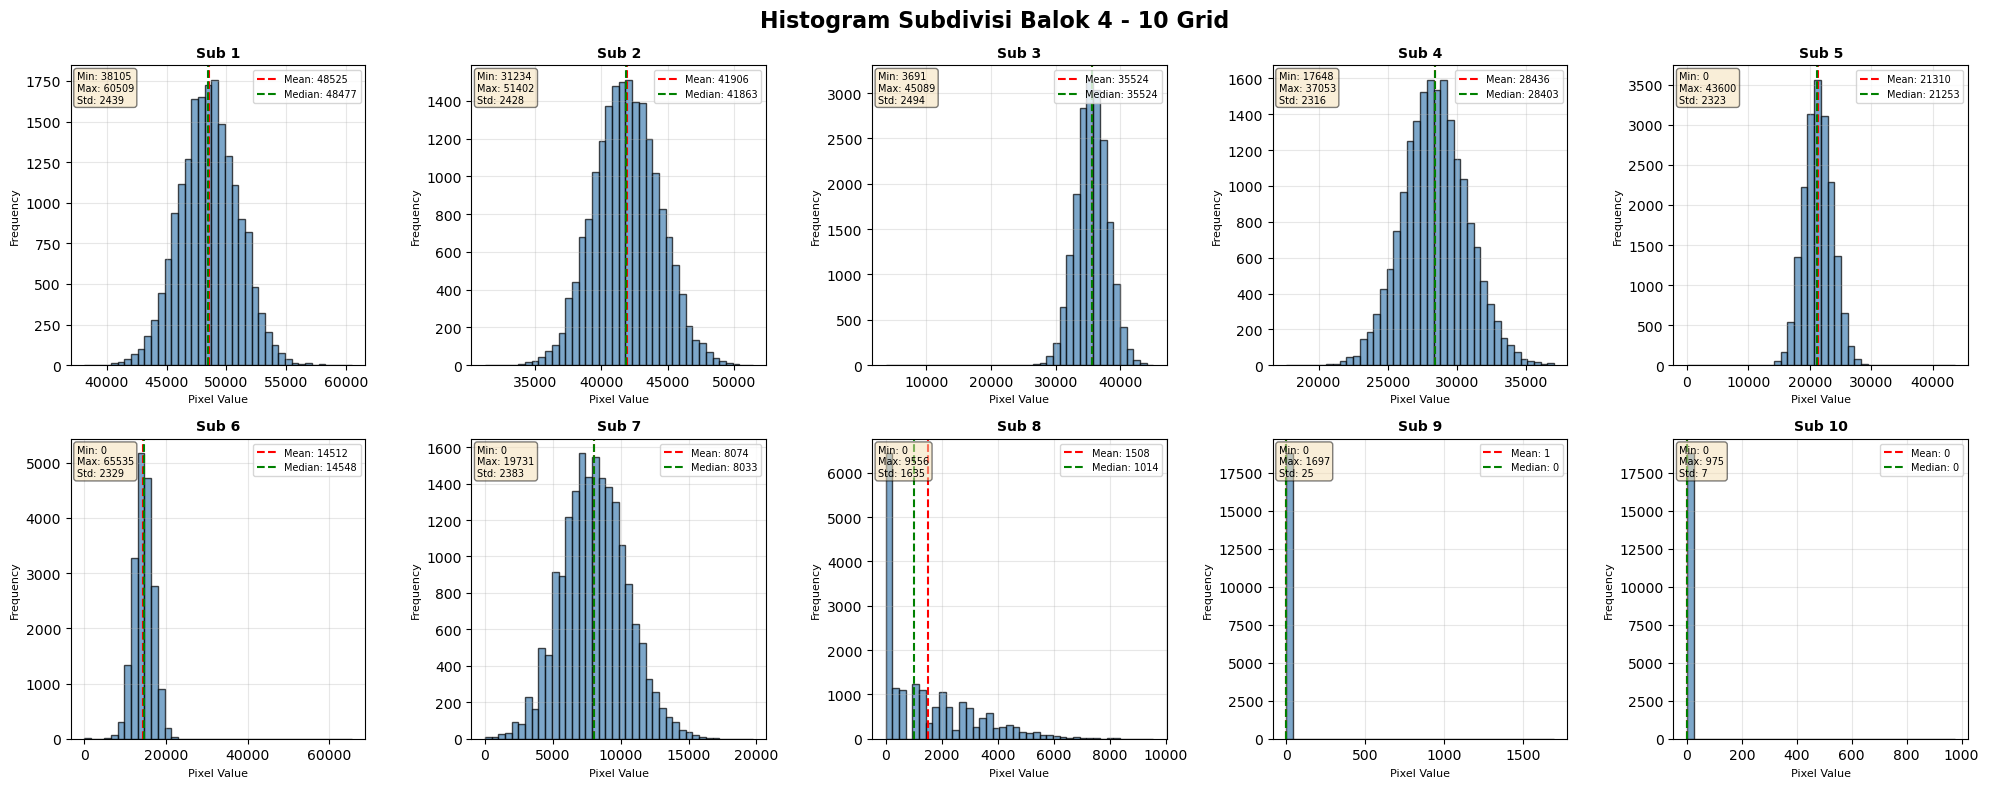

In [ ]:
def plot_subdivision_histograms(image_path, grid_subdivisions, block_number=1):
    """
    Plot histogram untuk setiap subdivisi dari balok tertentu.
    
    Parameters:
    -----------
    image_path : str
        Path ke file gambar
    grid_subdivisions : dict
        Hasil dari subdivide_blocks_into_grid
    block_number : int
        Nomor balok yang ingin dianalisis (default: 1)
    """
    # Load gambar
    img_16bit = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img_16bit is None:
        print("Error: Gambar tidak ditemukan.")
        return
    
    # Filter subdivisi untuk balok tertentu
    subdivisions = [s for s in grid_subdivisions['subdivisions'] if s['parent_block'] == block_number]
    
    if len(subdivisions) == 0:
        print(f"Tidak ada subdivisi untuk balok {block_number}")
        return
    
    num_subs = len(subdivisions)
    
    # Setup plot - 2 rows x 5 cols untuk 10 subdivisi
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    fig.suptitle(f'Histogram Subdivisi Balok {block_number} - {num_subs} Grid', 
                 fontsize=16, fontweight='bold')
    
    print("=" * 100)
    print(f"=== STATISTIK SUBDIVISI BALOK {block_number} ===")
    print("=" * 100)
    print(f"{'Sub':<4} | {'Center':<20} | {'Mean':<10} | {'Median':<10} | {'Std':<10} | {'Range'}")
    print("-" * 100)
    
    for idx, sub in enumerate(subdivisions):
        center = sub['center']
        box = sub['box']
        
        # Buat mask untuk area balok kecil
        mask = np.zeros_like(img_16bit, dtype=np.uint8)
        cv2.drawContours(mask, [box], 0, 255, -1)
        
        # Ekstrak pixel values
        pixel_values = img_16bit[mask == 255]
        
        if len(pixel_values) == 0:
            print(f"{sub['subdivision_id']:<4} | {str(center):<20} | No pixels")
            continue
        
        # Hitung statistik
        mean_val = np.mean(pixel_values)
        median_val = np.median(pixel_values)
        std_val = np.std(pixel_values)
        min_val = np.min(pixel_values)
        max_val = np.max(pixel_values)
        
        # Plot histogram
        ax = axes[idx]
        ax.hist(pixel_values, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Garis mean dan median
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
                  label=f'Mean: {mean_val:.0f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=1.5, 
                  label=f'Median: {median_val:.0f}')
        
        # Title
        ax.set_title(f'Sub {sub["subdivision_id"]}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Pixel Value', fontsize=8)
        ax.set_ylabel('Frequency', fontsize=8)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)
        
        # Statistik box
        stats_text = f'Min: {min_val:.0f}\nMax: {max_val:.0f}\nStd: {std_val:.0f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                fontsize=7, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        print(f"{sub['subdivision_id']:<4} | {str(center):<20} | {mean_val:<10.1f} | "
              f"{median_val:<10.1f} | {std_val:<10.1f} | [{min_val:.0f}-{max_val:.0f}]")
    
    plt.tight_layout()
    plt.show()
    
    print("=" * 100)


# Run histogram analysis untuk semua balok
if 'grid_subdivisions' in locals():
    # Plot histogram untuk balok 1
    plot_subdivision_histograms(image_file, grid_subdivisions, block_number=1)
    
    # Plot histogram untuk balok 2
    if grid_subdivisions['num_blocks'] >= 2:
        plot_subdivision_histograms(image_file, grid_subdivisions, block_number=2)
    
    # Plot histogram untuk balok 3
    if grid_subdivisions['num_blocks'] >= 3:
        plot_subdivision_histograms(image_file, grid_subdivisions, block_number=3)
    
    # Plot histogram untuk balok 4
    if grid_subdivisions['num_blocks'] >= 4:
        plot_subdivision_histograms(image_file, grid_subdivisions, block_number=4)
else:
    print("Run subdivisi cell terlebih dahulu!")

## Compare Balok 1 vs Balok 3 (Subdivisions)

Bandingkan subdivisi dari balok 1 dan balok 3 secara berpasangan.

=== PERBANDINGAN BALOK 1 vs BALOK 3 (Subdivisi Sejajar) ===
Sub  | Balok 1 Mean    | Balok 3 Mean    | Diff       | B1 Median       | B3 Median       | Diff      
------------------------------------------------------------------------------------------------------------------------
1    | 51250.4         | 52387.1         | -1136.7    | 51162.0         | 52383.0         | -1221.0   
2    | 49042.4         | 51847.1         | -2804.7    | 49101.0         | 51822.0         | -2721.0   
3    | 46572.8         | 51529.6         | -4956.9    | 46566.0         | 51610.0         | -5044.0   
4    | 45191.2         | 50582.8         | -5391.6    | 45185.0         | 50612.0         | -5427.0   
5    | 43336.2         | 49670.4         | -6334.3    | 43297.0         | 49722.0         | -6425.0   
6    | 41575.2         | 48968.4         | -7393.2    | 41604.0         | 49027.0         | -7423.0   
7    | 41518.2         | 50136.8         | -8618.6    | 41534.0         | 50098.0         | -8564.

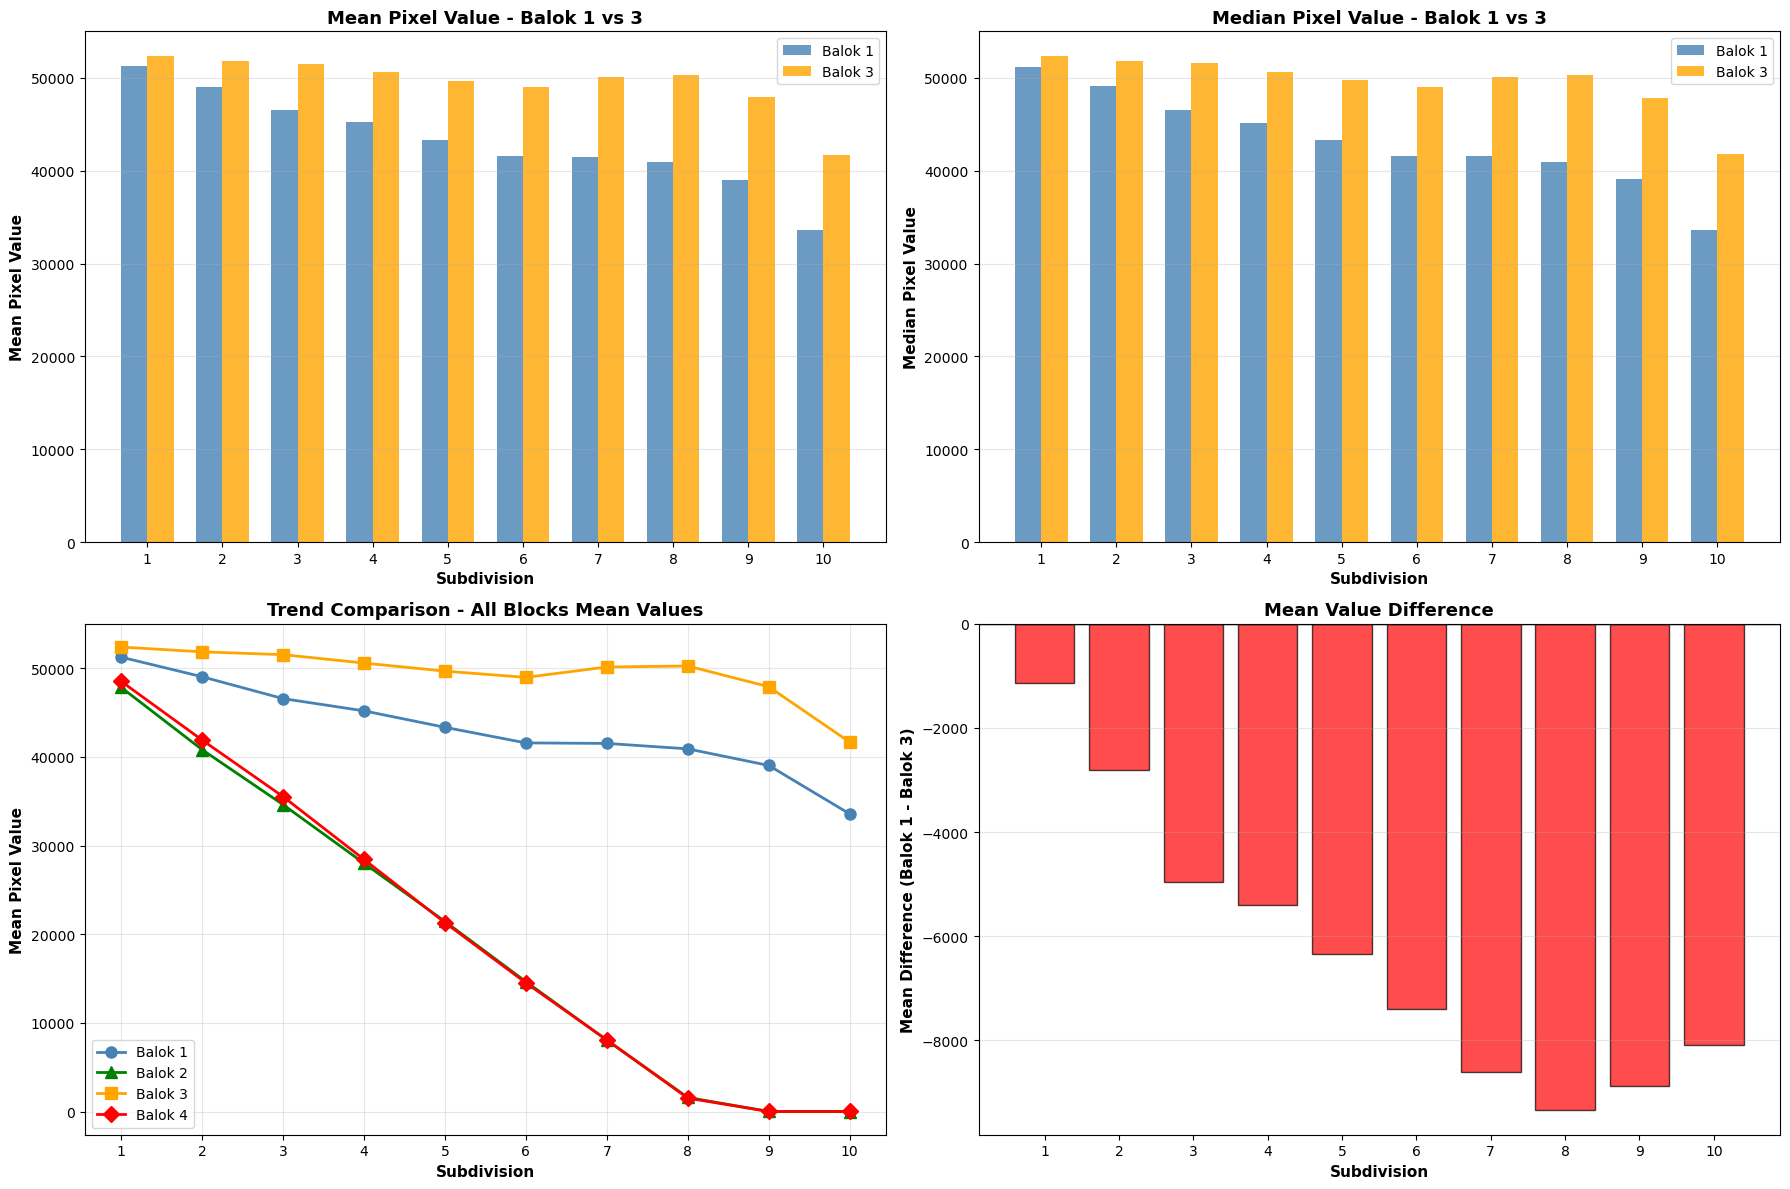


=== SUMMARY ===

Balok 1:
  Mean average: 43199.2 ± 4849.4
  Median average: 43204.0 ± 4829.0

Balok 2:
  Mean average: 19699.9 ± 16728.4

Balok 3:
  Mean average: 49495.2 ± 2903.6
  Median average: 49518.5 ± 2875.7

Balok 4:
  Mean average: 19979.7 ± 17093.1

Difference (Balok 1 - Balok 3):
  Mean difference: -6296.0 ± 2593.2
  Range: -9346.7 to -1136.7


In [ ]:
def compare_block1_vs_block3(image_path, grid_subdivisions):
    """
    Bandingkan subdivisi balok 1 vs balok 3 (yang sejajar).
    Asumsi: Balok 1 = parent_block 1, Balok 3 = parent_block 3
    """
    # Load gambar
    img_16bit = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img_16bit is None:
        print("Error: Gambar tidak ditemukan.")
        return
    
    subdivisions = grid_subdivisions['subdivisions']
    
    # Pisahkan subdivisi berdasarkan parent block
    block1_subs = [s for s in subdivisions if s['parent_block'] == 1]
    block2_subs = [s for s in subdivisions if s['parent_block'] == 2]
    block3_subs = [s for s in subdivisions if s['parent_block'] == 3]
    block4_subs = [s for s in subdivisions if s['parent_block'] == 4]
    
    if len(block1_subs) == 0 or len(block3_subs) == 0:
        print("Error: Tidak cukup data untuk membandingkan balok")
        return
    
    # Hitung statistik untuk balok 1
    block1_stats = []
    for sub in block1_subs:
        mask = np.zeros_like(img_16bit, dtype=np.uint8)
        cv2.drawContours(mask, [sub['box']], 0, 255, -1)
        pixel_values = img_16bit[mask == 255]
        
        if len(pixel_values) > 0:
            block1_stats.append({
                'subdivision_id': sub['subdivision_id'],
                'label': f"1.{sub['subdivision_id']}",
                'mean': np.mean(pixel_values),
                'median': np.median(pixel_values),
                'std': np.std(pixel_values)
            })
    
    # Hitung statistik untuk balok 2
    block2_stats = []
    for sub in block2_subs:
        mask = np.zeros_like(img_16bit, dtype=np.uint8)
        cv2.drawContours(mask, [sub['box']], 0, 255, -1)
        pixel_values = img_16bit[mask == 255]
        
        if len(pixel_values) > 0:
            block2_stats.append({
                'subdivision_id': sub['subdivision_id'],
                'label': f"2.{sub['subdivision_id']}",
                'mean': np.mean(pixel_values),
                'median': np.median(pixel_values),
                'std': np.std(pixel_values)
            })
    
    # Hitung statistik untuk balok 3
    block3_stats = []
    for sub in block3_subs:
        mask = np.zeros_like(img_16bit, dtype=np.uint8)
        cv2.drawContours(mask, [sub['box']], 0, 255, -1)
        pixel_values = img_16bit[mask == 255]
        
        if len(pixel_values) > 0:
            block3_stats.append({
                'subdivision_id': sub['subdivision_id'],
                'label': f"3.{sub['subdivision_id']}",
                'mean': np.mean(pixel_values),
                'median': np.median(pixel_values),
                'std': np.std(pixel_values)
            })
    
    # Hitung statistik untuk balok 4
    block4_stats = []
    for sub in block4_subs:
        mask = np.zeros_like(img_16bit, dtype=np.uint8)
        cv2.drawContours(mask, [sub['box']], 0, 255, -1)
        pixel_values = img_16bit[mask == 255]
        
        if len(pixel_values) > 0:
            block4_stats.append({
                'subdivision_id': sub['subdivision_id'],
                'label': f"4.{sub['subdivision_id']}",
                'mean': np.mean(pixel_values),
                'median': np.median(pixel_values),
                'std': np.std(pixel_values)
            })
    
    # Visualisasi perbandingan
    num_subs = min(len(block1_stats), len(block2_stats), len(block3_stats), len(block4_stats))
    x_pos = np.arange(num_subs)
    
    block1_means = [s['mean'] for s in block1_stats[:num_subs]]
    block2_means = [s['mean'] for s in block2_stats[:num_subs]]
    block3_means = [s['mean'] for s in block3_stats[:num_subs]]
    block4_means = [s['mean'] for s in block4_stats[:num_subs]]
    block1_medians = [s['median'] for s in block1_stats[:num_subs]]
    block3_medians = [s['median'] for s in block3_stats[:num_subs]]
    block1_stds = [s['std'] for s in block1_stats[:num_subs]]
    block3_stds = [s['std'] for s in block3_stats[:num_subs]]
    
    # Print comparison table
    print("=" * 120)
    print("=== PERBANDINGAN BALOK 1 vs BALOK 3 (Subdivisi Sejajar) ===")
    print("=" * 120)
    print(f"{'Sub':<4} | {'Balok 1 Mean':<15} | {'Balok 3 Mean':<15} | {'Diff':<10} | "
          f"{'B1 Median':<15} | {'B3 Median':<15} | {'Diff':<10}")
    print("-" * 120)
    
    for i in range(num_subs):
        mean_diff = block1_means[i] - block3_means[i]
        median_diff = block1_medians[i] - block3_medians[i]
        print(f"{i+1:<4} | {block1_means[i]:<15.1f} | {block3_means[i]:<15.1f} | {mean_diff:<10.1f} | "
              f"{block1_medians[i]:<15.1f} | {block3_medians[i]:<15.1f} | {median_diff:<10.1f}")
    
    print("=" * 120)
    
    # Plot comparison
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Plot 1: Mean comparison - Side by side bars
    ax1 = axes[0, 0]
    width = 0.35
    ax1.bar(x_pos - width/2, block1_means, width, label='Balok 1', alpha=0.8, color='steelblue')
    ax1.bar(x_pos + width/2, block3_means, width, label='Balok 3', alpha=0.8, color='orange')
    ax1.set_xlabel('Subdivision', fontweight='bold', fontsize=11)
    ax1.set_ylabel('Mean Pixel Value', fontweight='bold', fontsize=11)
    ax1.set_title('Mean Pixel Value - Balok 1 vs 3', fontweight='bold', fontsize=13)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f"{i+1}" for i in range(num_subs)])
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Median comparison
    ax2 = axes[0, 1]
    ax2.bar(x_pos - width/2, block1_medians, width, label='Balok 1', alpha=0.8, color='steelblue')
    ax2.bar(x_pos + width/2, block3_medians, width, label='Balok 3', alpha=0.8, color='orange')
    ax2.set_xlabel('Subdivision', fontweight='bold', fontsize=11)
    ax2.set_ylabel('Median Pixel Value', fontweight='bold', fontsize=11)
    ax2.set_title('Median Pixel Value - Balok 1 vs 3', fontweight='bold', fontsize=13)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f"{i+1}" for i in range(num_subs)])
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Line plot for trend - All 4 blocks
    ax3 = axes[1, 0]
    ax3.plot(x_pos, block1_means, marker='o', linewidth=2, markersize=8, 
            label='Balok 1', color='steelblue')
    ax3.plot(x_pos, block2_means, marker='^', linewidth=2, markersize=8, 
            label='Balok 2', color='green')
    ax3.plot(x_pos, block3_means, marker='s', linewidth=2, markersize=8, 
            label='Balok 3', color='orange')
    ax3.plot(x_pos, block4_means, marker='D', linewidth=2, markersize=8, 
            label='Balok 4', color='red')
    ax3.set_xlabel('Subdivision', fontweight='bold', fontsize=11)
    ax3.set_ylabel('Mean Pixel Value', fontweight='bold', fontsize=11)
    ax3.set_title('Trend Comparison - All Blocks Mean Values', fontweight='bold', fontsize=13)
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([f"{i+1}" for i in range(num_subs)])
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Difference plot
    ax4 = axes[1, 1]
    mean_diffs = [block1_means[i] - block3_means[i] for i in range(num_subs)]
    colors_diff = ['green' if d > 0 else 'red' for d in mean_diffs]
    ax4.bar(x_pos, mean_diffs, color=colors_diff, alpha=0.7, edgecolor='black')
    ax4.axhline(0, color='black', linewidth=1, linestyle='-')
    ax4.set_xlabel('Subdivision', fontweight='bold', fontsize=11)
    ax4.set_ylabel('Mean Difference (Balok 1 - Balok 3)', fontweight='bold', fontsize=11)
    ax4.set_title('Mean Value Difference', fontweight='bold', fontsize=13)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([f"{i+1}" for i in range(num_subs)])
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n" + "=" * 120)
    print("=== SUMMARY ===")
    print("=" * 120)
    print(f"\nBalok 1:")
    print(f"  Mean average: {np.mean(block1_means):.1f} ± {np.std(block1_means):.1f}")
    print(f"  Median average: {np.mean(block1_medians):.1f} ± {np.std(block1_medians):.1f}")
    print(f"\nBalok 2:")
    print(f"  Mean average: {np.mean(block2_means):.1f} ± {np.std(block2_means):.1f}")
    print(f"\nBalok 3:")
    print(f"  Mean average: {np.mean(block3_means):.1f} ± {np.std(block3_means):.1f}")
    print(f"  Median average: {np.mean(block3_medians):.1f} ± {np.std(block3_medians):.1f}")
    print(f"\nBalok 4:")
    print(f"  Mean average: {np.mean(block4_means):.1f} ± {np.std(block4_means):.1f}")
    print(f"\nDifference (Balok 1 - Balok 3):")
    print(f"  Mean difference: {np.mean(mean_diffs):.1f} ± {np.std(mean_diffs):.1f}")
    print(f"  Range: {np.min(mean_diffs):.1f} to {np.max(mean_diffs):.1f}")
    print("=" * 120)
    
    return {
        'block1': block1_stats,
        'block2': block2_stats,
        'block3': block3_stats,
        'block4': block4_stats,
        'mean_differences': mean_diffs
    }


# Run comparison balok 1 vs 3
if 'grid_subdivisions' in locals():
    comparison_result = compare_block1_vs_block3(image_file, grid_subdivisions)
else:
    print("Run subdivisi cell terlebih dahulu!")
